# The Comparison between the noiseless simulated galaxy flux and the flux recovered after denoising with the standard N2V.

In [26]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d

# We generate 2 sets of galaxy.

In [2]:
path = '../data saved/'

stamps_ori = np.load(path + 'stampcor.npy')
stamps_cle = np.load(path + 'stampcle.npy')

stamps_ori_small = np.load(path + 'stampcor_small.npy')
stamps_cle_small = np.load(path + 'stampcle_small.npy')

In [3]:
import os
os.chdir('../pn2v/src/pn2v')
from unet import UNet
from core import utils
import torch
from core import prediction
device=utils.getDevice()

os.chdir('../../..')
os.chdir('./model saved')

net=torch.load("N2V_simulation2.net", weights_only=False)

CUDA available? True


In [4]:
value_denoise = np.zeros(len(stamps_ori))
value_noise = np.zeros(len(stamps_ori))
value_clean = np.zeros(len(stamps_ori))
value_background_noise = np.zeros(len(stamps_ori))
value_background_denoise = np.zeros(len(stamps_ori))
value_background_clean = np.zeros(len(stamps_ori))

image_size = 96
mask = np.zeros((image_size, image_size), dtype=bool)

x_inner, y_inner = 20, 76 
x_outer, y_outer = 10, 86 

mask[x_outer:y_outer, x_outer:y_outer] = True
mask[x_inner:y_inner, x_inner:y_inner] = False


for i in tqdm(range(len(stamps_ori))):
    
    n2vResult = prediction.tiledPredict(stamps_ori[i], net, ps=96, overlap=48,
                                            device=device, noiseModel=None)
    value_noise[i] = np.sum(stamps_ori[i][42:54,42:54])
    value_clean[i] = np.sum(stamps_cle[i][42:54,42:54])
    value_background_noise[i] = np.mean(stamps_ori[i][mask]) * 144
    value_denoise[i] = np.sum(n2vResult[42:54,42:54])
    value_background_clean[i] = np.mean(stamps_cle[i][mask]) * 144
    value_background_denoise[i] = np.mean(n2vResult[mask]) * 144 

100%|██████████| 2400/2400 [00:11<00:00, 216.48it/s]


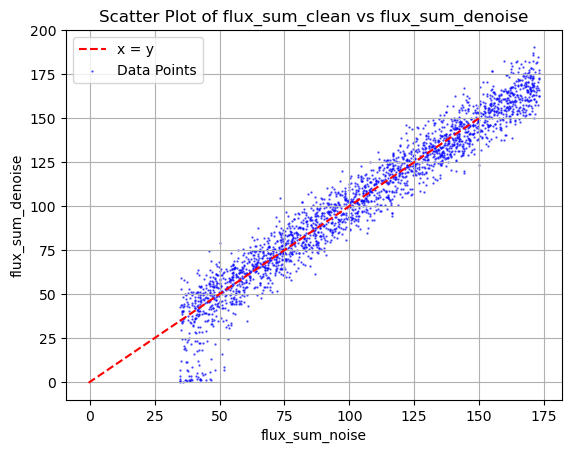

In [5]:
x = np.linspace(-0.5, 150, 1000) 
y = x 
#z = 2/3 * x
plt.plot(x, y, 'r--', label="x = y")
plt.scatter(value_clean - value_background_clean, value_denoise - value_background_denoise, 
            label="Data Points", color='b', alpha=0.6, s=0.5)

plt.xlabel("flux_sum_noise")
plt.ylabel("flux_sum_denoise")
plt.title("Scatter Plot of flux_sum_clean vs flux_sum_denoise")

#plt.xlim(0, 20)  
#plt.ylim(0, 20) 

plt.legend()
plt.grid(True)
plt.show()

# Make the fainter set smaller to get the points in the fainter part (x < 30)

In [6]:
stamps_ori_small1 = stamps_ori_small.copy() * 0.98
stamps_cle_small1 = stamps_cle_small.copy() * 0.98

In [7]:
value_denoise_small1 = np.zeros(len(stamps_ori_small1))
value_noise_small1 = np.zeros(len(stamps_ori_small1))
value_clean_small1 = np.zeros(len(stamps_ori_small1))
value_background_noise_small1 = np.zeros(len(stamps_ori_small1))
value_background_denoise_small1 = np.zeros(len(stamps_ori_small1))
value_background_clean_small1 = np.zeros(len(stamps_ori_small1))

image_size = 96
mask = np.zeros((image_size, image_size), dtype=bool)

x_inner, y_inner = 20, 76 
x_outer, y_outer = 10, 86 

mask[x_outer:y_outer, x_outer:y_outer] = True
mask[x_inner:y_inner, x_inner:y_inner] = False


for i in tqdm(range(len(stamps_ori_small1))):
    
    n2vResult_800 = prediction.predict_Jiefeng(stamps_ori_small1[i], net ,device=device,noiseModel=None)
    
    value_noise_small1[i] = np.sum(stamps_ori_small1[i][42:54,42:54])
    value_clean_small1[i] = np.sum(stamps_cle_small1[i][42:54,42:54])
    value_background_noise_small1[i] = np.mean(stamps_ori_small1[i][mask]) * 144
    value_denoise_small1[i] = np.sum(n2vResult_800[1][42:54,42:54])
    value_background_clean_small1[i] = np.mean(stamps_cle_small1[i][mask]) * 144
    value_background_denoise_small1[i] = np.mean(n2vResult_800[1][mask]) * 144 

100%|██████████| 2400/2400 [00:17<00:00, 133.66it/s]


In [8]:
indices = np.random.choice(2400, size=300, replace=False)
selected_clean1 = value_clean_small1[indices]
selected_clean_background1 = value_background_clean_small1[indices]

selected_denoise1 = value_denoise_small1[indices]
selected_denoise_background1 = value_background_denoise_small1[indices]

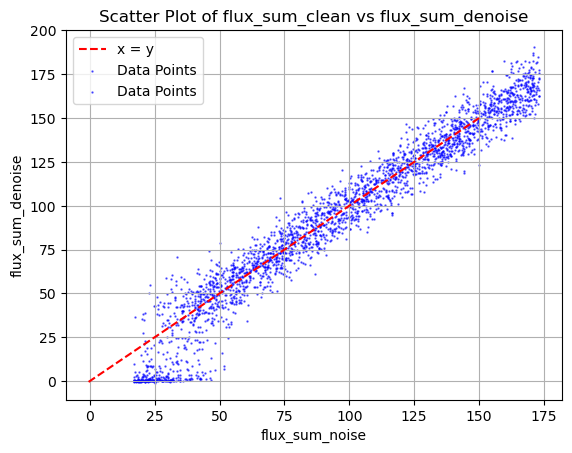

In [9]:
x = np.linspace(-0.5, 150, 1000) 
y = x 
#z = 2/3 * x
plt.plot(x, y, 'r--', label="x = y")
plt.scatter(selected_clean1 - selected_clean_background1, selected_denoise1 - selected_denoise_background1, 
            label="Data Points", color='b', alpha=0.6, s=0.5)

plt.scatter(value_clean - value_background_clean, value_denoise - value_background_denoise, 
            label="Data Points", color='b', alpha=0.6, s=0.5)

plt.xlabel("flux_sum_noise")
plt.ylabel("flux_sum_denoise")
plt.title("Scatter Plot of flux_sum_clean vs flux_sum_denoise")

#plt.xlim(0, 20)  
#plt.ylim(0, 20) 

plt.legend()
plt.grid(True)
plt.show()

# Fainter

In [22]:
stamps_ori_small2 = stamps_ori_small.copy() * 0.49
stamps_cle_small2 = stamps_cle_small.copy() * 0.49

In [23]:
value_denoise_small2 = np.zeros(len(stamps_ori_small2))
value_noise_small2 = np.zeros(len(stamps_ori_small2))
value_clean_small2 = np.zeros(len(stamps_ori_small2))
value_background_noise_small2 = np.zeros(len(stamps_ori_small2))
value_background_denoise_small2 = np.zeros(len(stamps_ori_small2))
value_background_clean_small2 = np.zeros(len(stamps_ori_small2))

image_size = 96
mask = np.zeros((image_size, image_size), dtype=bool)

x_inner, y_inner = 20, 76  
x_outer, y_outer = 10, 86 

mask[x_outer:y_outer, x_outer:y_outer] = True
mask[x_inner:y_inner, x_inner:y_inner] = False


for i in tqdm(range(len(stamps_ori_small2))):
    
    n2vResult_800 = prediction.predict_Jiefeng(stamps_ori_small2[i], net ,device=device,noiseModel=None)
    
    value_noise_small2[i] = np.sum(stamps_ori_small2[i][42:54,42:54])
    value_clean_small2[i] = np.sum(stamps_cle_small2[i][42:54,42:54])
    value_background_noise_small2[i] = np.mean(stamps_ori_small2[i][mask]) * 144
    value_denoise_small2[i] = np.sum(n2vResult_800[1][42:54,42:54])
    value_background_clean_small2[i] = np.mean(stamps_cle_small2[i][mask]) * 144
    value_background_denoise_small2[i] = np.mean(n2vResult_800[1][mask]) * 144 

100%|██████████| 2400/2400 [00:16<00:00, 143.00it/s]


In [24]:
indices = np.random.choice(2400, size=200, replace=False)
selected_clean2 = value_clean_small2[indices]
selected_clean_background2 = value_background_clean_small2[indices]

selected_denoise2 = value_denoise_small2[indices]
selected_denoise_background2 = value_background_denoise_small2[indices]

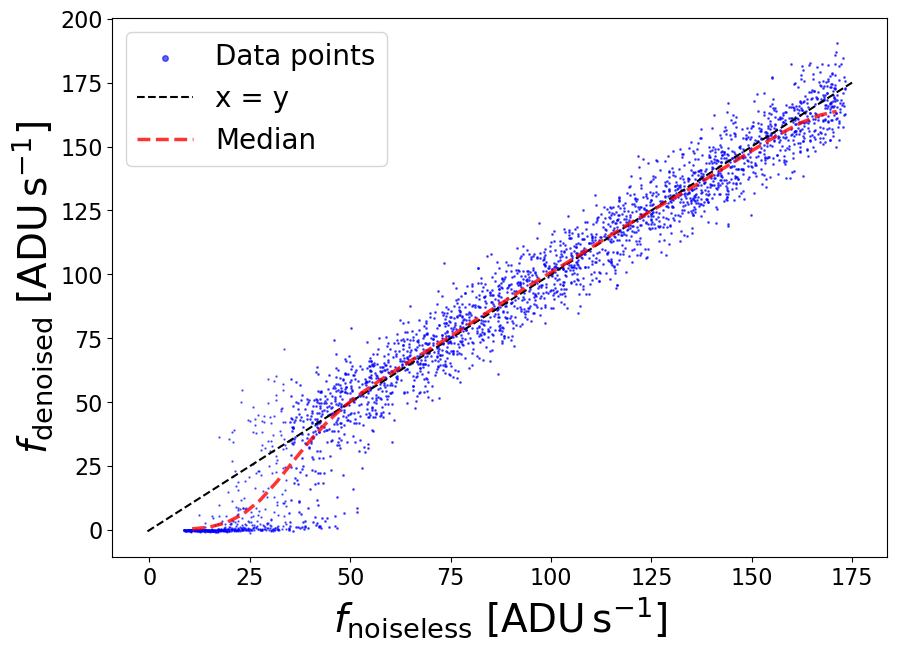

In [41]:
plt.figure(figsize=(10, 7), dpi=100)

x = np.linspace(-0.5, 175, 1000) 
y = x 

x1 = selected_clean1 - selected_clean_background1
y1 = selected_denoise1 - selected_denoise_background1
plt.scatter(x1, y1, color='b', alpha=0.6, s=0.5)

x2 = selected_clean2 - selected_clean_background2
y2 = selected_denoise2 - selected_denoise_background2
plt.scatter(x2, y2, color='b', alpha=0.6, s=0.5)

x3 = value_clean - value_background_clean
y3 = value_denoise - value_background_denoise
plt.scatter(x3, y3, label='Data points', color='b', alpha=0.6, s=1)
plt.plot(x, y, '--',color='black' ,label="x = y", zorder=3)

x_all = np.concatenate([x1, x2, x3])
y_all = np.concatenate([y1, y2, y3])

valid_mask = np.isfinite(x_all) & np.isfinite(y_all)
x_valid = x_all[valid_mask]
y_valid = y_all[valid_mask]

bins = np.linspace(x_valid.min(), x_valid.max(), 40)

bin_medians, bin_edges, _ = binned_statistic(x_valid, y_valid, statistic='median', bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

valid_bins = ~np.isnan(bin_medians)
bc_clean = bin_centers[valid_bins]
bm_clean = bin_medians[valid_bins]

bm_smooth = gaussian_filter1d(bm_clean, sigma=2)
plt.plot(bc_clean, bm_smooth,'r--', linewidth=2.5,label="Median",alpha=0.8, zorder=4)
plt.xlabel(r'$f_{\text{noiseless}}$ $[\mathrm{ADU}\,\mathrm{s}^{-1}]$', fontsize=28)
plt.ylabel(r'$f_{\text{denoised}}$ $[\mathrm{ADU}\,\mathrm{s}^{-1}]$', fontsize=28)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=20,markerscale=4)